# Lazy raster reads + parallel writes with `Dataset` and `DatasetCollection`

This notebook exercises the **dask-backed** raster path end to end: a lazy chunked read, a per-tile kernel with
`map_blocks`, a truly-parallel Zarr write, and a 4-D temporal cube reduced across time. It runs entirely on the
**local** rasters shipped with pyramids, so it executes offline in a few seconds.

The exact same code path scales to **cloud COGs** — pass an `s3://…` / `https://…` URL to `read_file` and GDAL's
`/vsicurl/` layer fetches only the block-ranges dask asks for. The only extras for cloud are
`configure(cloud_defaults=True)` (sets GDAL's HTTP/caching env vars) and a bigger scheduler; see the
*Further reading* links at the end for the Sentinel-2-on-AWS variant.

## What you'll see

1. Lazy raster reads via `Dataset.read_array(chunks=...)` — a graph of per-tile tasks, nothing materialised.
2. `Dataset.map_blocks(func, chunks=...)` — apply a numpy kernel across every tile in parallel.
3. Parallel Zarr writes — `Dataset.to_zarr(store, compute=False)` returns a `Delayed`; `.compute()` writes every
   tile.
4. `DatasetCollection.from_files(...)` over a ten-day series — a 4-D lazy cube you reduce across time.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'
```

## Setup

`%matplotlib inline` draws plots inline. We resolve `DATA` to the repo's `examples/data/` folder relative to this
notebook. Dask runs on its default **threaded** scheduler here — fine for the I/O-bound reads below; for CPU-bound
kernels on a real workload you would switch to `dask.config.set(scheduler="processes")` or a
`distributed.LocalCluster`, and for cloud COGs add `from pyramids import configure; configure(cloud_defaults=True)`.

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_chunk_grid(arr, title):
    # Draw the dask chunk boundaries over the array's row/column extent.
    ny, nx = arr.shape[-2], arr.shape[-1]
    ys, xs = np.cumsum((0,) + arr.chunks[-2]), np.cumsum((0,) + arr.chunks[-1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    for y0, y1 in zip(ys[:-1], ys[1:]):
        for x0, x1 in zip(xs[:-1], xs[1:]):
            ax.add_patch(
                plt.Rectangle(
                    (x0, y0), x1 - x0, y1 - y0, fill=False, ec='crimson', lw=1.4
                )
            )
    ax.set(xlim=(0, nx), ylim=(ny, 0), title=title, xlabel='columns', ylabel='rows')
    ax.set_aspect('equal')
    return fig


DATA = (Path('..') / '..' / '..' / 'examples' / 'data').resolve()
DATA.is_dir()

True

## 1. Open a scene as a lazy Dataset

We open a 780 × 850 MSWEP precipitation scene. `read_file` only reads the header; `read_array(chunks=...)` is what
turns the band into a **dask array** — a graph of per-tile read tasks, still nothing materialised. Displaying it
shows the chunk grid: at `256 × 256` the band tiles into a **4 × 4 grid of 16 chunks**.

| `chunks` value | Meaning |
| --- | --- |
| `"auto"` | Match the file's internal block shape — ideal for a COG (typically 1024 × 1024 tiles) |
| `int` / tuple | Force an explicit chunk shape, in pixels |
| `-1` | One chunk for the whole band (behaves eagerly) |

The local GeoTIFF here is stored in strips rather than tiles, so `"auto"` would return a single chunk — we pass an
explicit `256 × 256` to get a real grid. On a cloud COG, `"auto"` aligns each dask task to one HTTP range read.

In [2]:
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'geotiff' / 'south-america-mswep_1979010100.tif')
(ds.rows, ds.columns), ds.epsg, ds.cell_size

((780, 850), 4326, 0.1)

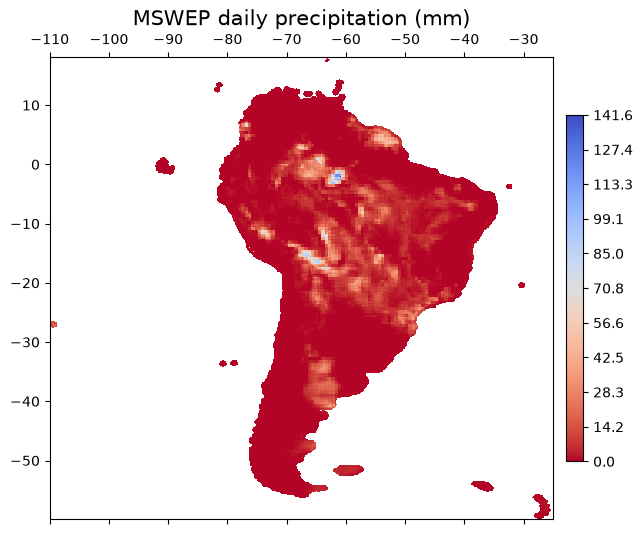

In [3]:
ds.plot(band=0, title="MSWEP daily precipitation (mm)")

The lazy read — display it to see the chunk grid dask (and therefore GDAL's block requests) will use:

In [4]:
# Lazy read: nothing materialised yet.
lazy_band = ds.read_array(band=0, chunks=(256, 256))
lazy_band

dask.array<_read_chunk, shape=(780, 850), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>

If the HTML repr above doesn't render (it needs a *trusted* notebook), the same facts print as plain text, and the
chunk grid draws as an image — the 780 × 850 band cut into a 4 × 4 grid of 16 tiles. Each red box is one dask
chunk: one lazy read, one unit of parallel work, **zero** bytes fetched so far.

In [5]:
print("backend      :", type(lazy_band).__name__, "(dask.array — LAZY, not numpy)")
print("shape        :", lazy_band.shape, lazy_band.dtype)
print("chunk grid   :", lazy_band.numblocks, "->", lazy_band.npartitions, "chunks")
print("graph tasks  :", len(lazy_band.__dask_graph__()), "(one read per chunk)")
print("bytes read   : 0  (nothing computed yet)")

backend      : Array (dask.array — LAZY, not numpy)
shape        : (780, 850) float32
chunk grid   : (4, 4) -> 16 chunks
graph tasks  : 16 (one read per chunk)
bytes read   : 0  (nothing computed yet)


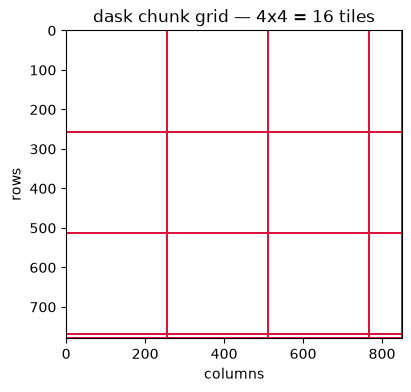

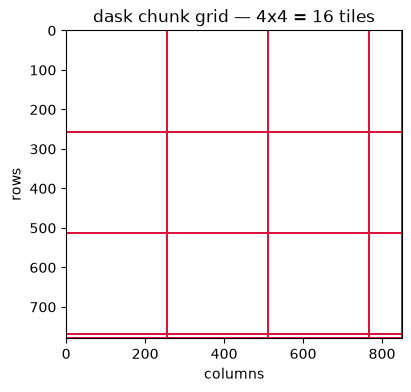

In [6]:
plot_chunk_grid(
    lazy_band,
    f"dask chunk grid — {lazy_band.numblocks[-2]}x{lazy_band.numblocks[-1]} "
    f"= {lazy_band.npartitions} tiles",
)

## 2. `map_blocks` — apply a numpy kernel across every tile in parallel

`Dataset.map_blocks` passes each dask chunk through a pure-numpy function, so every tile is processed independently
— the classic band-math pattern. Here the kernel clips the `-9999` ocean fill to zero and casts to float. The
result is another lazy dask array over the same 4 × 4 grid; no tile has been read yet.

In [7]:
def clean(arr: np.ndarray) -> np.ndarray:
    # Drop the -9999 fill (ocean / no-data) and cast to float.
    return np.clip(arr, 0.0, None).astype(np.float32)


rescaled = ds.map_blocks(clean, chunks=(256, 256), band=0)
rescaled

dask.array<clean, shape=(780, 850), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>

## 3. Parallel write via Zarr

`Dataset.to_zarr(store, compute=False)` returns a `dask.delayed.Delayed` that bundles the per-tile data write and
the geobox-metadata write into one graph. Calling `.compute()` is the moment work actually happens — every chunk
is written independently (in parallel under a process/distributed scheduler), producing one Zarr chunk file per
tile.

In [8]:
store = Path(tempfile.mkdtemp()) / "mswep_clean.zarr"
delayed = ds.to_zarr(store, compute=False)
type(delayed).__name__

'Delayed'

In [9]:
# Force the graph — every chunk writes under the scheduler configured above.
delayed.compute()
sorted(p.name for p in store.iterdir())[:5]

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

Read the store back and confirm the geobox survived the round-trip: matching `(rows, columns)` and `epsg` mean the
spatial metadata was written alongside the pixel data, so downstream consumers get a properly georeferenced array,
not a bare grid.

In [10]:
# Round-trip check — from_zarr hands back an eager Dataset.
recovered = Dataset.from_zarr(store)
(recovered.rows, recovered.columns), recovered.epsg

((780, 850), 4326)

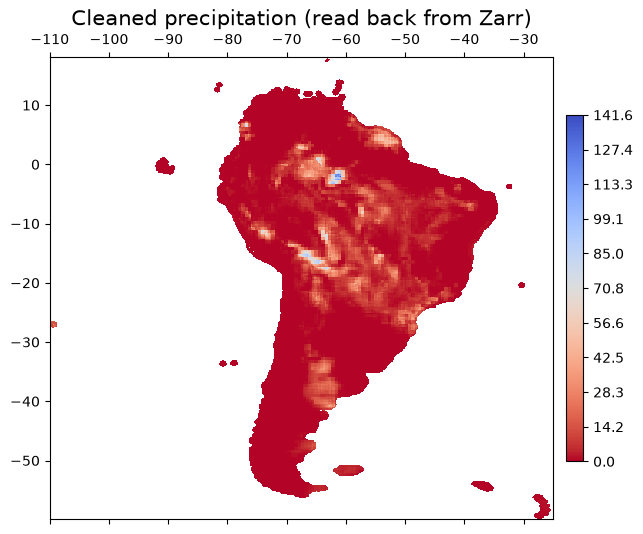

In [11]:
recovered.plot(band=0, title="Cleaned precipitation (read back from Zarr)")

## 4. A temporal cube with `DatasetCollection`

Ten aligned daily scenes form a 4-D `(T, B, R, C)` cube. `DatasetCollection.from_files(files)` does **not** open
them all up front; `.data` returns a lazy dask array chunked one file per timestep. A reduction across the time
axis (`.mean(axis=0)`) pulls only the chunks each output tile needs and streams them through the workers — the
cube is never fully held in one process.

In [12]:
from pyramids.dataset import DatasetCollection

# Ten aligned daily runoff rasters — the same MGRS-tile-over-time pattern, local.
files = sorted((DATA / 'geotiff' / 'rhine').glob('Qtot_*.tif'))
cube = DatasetCollection.from_files(files)
cube.time_length, cube.data.shape, cube.data.chunksize

(10, (10, 1, 125, 93), (1, 1, 125, 93))

In [13]:
# Temporal reduction — workers pull only the chunks they need for the mean.
time_mean = cube.data.mean(axis=0).compute()
time_mean.shape, float(np.nanmean(time_mean))

((1, 125, 93), 22.64785376344086)

### Plot a single timestep of the cube

The cube stays lazy, but `iloc(0)` materialises the first day as an eager `Dataset` — a cheap visual sanity check
alongside the temporal reduction above.

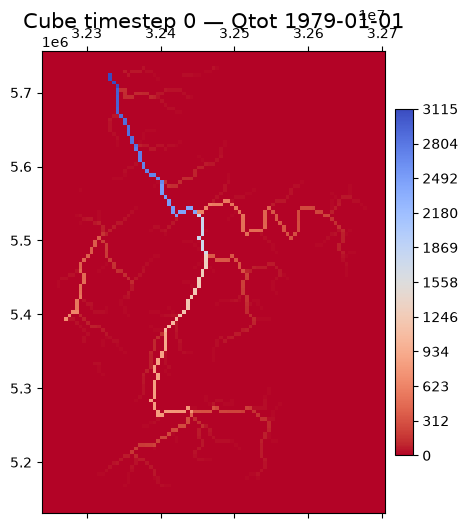

In [14]:
cube.iloc(0).plot(band=0, title="Cube timestep 0 — Qtot 1979-01-01")

### Cube → Zarr for downstream consumers

`DatasetCollection.to_zarr(store)` writes a CF-compatible Zarr store (blocking until every partition lands).
Downstream xarray / rioxarray consumers can open it without pyramids.

In [15]:
cube_store = Path(tempfile.mkdtemp()) / "qtot_cube.zarr"
cube.to_zarr(cube_store)
sorted(p.name for p in cube_store.iterdir())[:5]

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

## Further reading

- The same `read_file` / `read_array(chunks=...)` path runs on cloud COGs — pass an `s3://…` or
  `https://…/B04.tif` URL and add `configure(cloud_defaults=True)`.
- [Sentinel-2 L2A COGs — AWS Registry of Open Data](https://registry.opendata.aws/sentinel-2-l2a-cogs/)
- [Earth Search STAC API](https://earth-search.aws.element84.com/v1) — discover scenes by bbox + date, then feed
  the hrefs to `DatasetCollection.from_stac(...)`.
- [planning/dask/integration-plan.md](../../../planning/dask/integration-plan.md) — full DASK task tracker.